In [2]:
# --- 0. Essential Imports ---
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

%matplotlib inline

print("All necessary libraries imported.")

# --- 3.1 Load the Dataset ---
# Load the dataset 'Online Retail.xlsx'
try:
    df = pd.read_excel('Online Retail.xlsx')
    print("\nDataset 'Online Retail.xlsx' loaded successfully!")
except FileNotFoundError:
    print("\nError: 'Online Retail.xlsx' not found.")
    print("Please make sure the file is in the same directory as this notebook, or provide the full path to the file.")
    exit()


All necessary libraries imported.

Dataset 'Online Retail.xlsx' loaded successfully!


In [4]:
#  FILTER THE DATA FOR 'UNITED KINGDOM' ONLY ===
# =========================================================================
print("\n--- Filtering Data for 'United Kingdom' ---")
df_uk = df[df['Country'] == 'United Kingdom'].copy()
print(f"Original shape: {df.shape}")
print(f"Shape after filtering for 'United Kingdom': {df_uk.shape}")

# Now, we'll work with the filtered DataFrame 'df_uk' for all subsequent steps.
df = df_uk


# --- 3.2 Initial Data Exploration (EDA) ---
print("\n--- Initial Data Overview (from loaded and filtered data) ---")
print("Original Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Unique values in Description (before cleaning):", df['Description'].nunique())
print("Unique values in InvoiceNo (before cleaning):", df['InvoiceNo'].nunique())


# --- 3.3 Data Cleaning & Transformation (Initial Pass) ---
print("\n--- Data Cleaning Process ---")
df.dropna(subset=['InvoiceNo', 'Description'], inplace=True)
print(f"Shape after dropping NaNs in InvoiceNo/Description: {df.shape}")
df['Description'] = df['Description'].str.strip()
print("Item descriptions stripped of leading/trailing spaces.")
df = df[~df['InvoiceNo'].astype(str).str.contains('C', na=False)]
df = df[df['Quantity'] > 0]
print("Removed cancelled orders and items with negative quantities.")
print(f"Shape after handling cancellations and negative quantities: {df.shape}")
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
print("InvoiceNo column converted to string type.")


# --- NEW STEP: Reduce the Dataset Size (Sampling Transactions) ---
print("\n--- Transaction Sampling ---")
unique_invoices = df['InvoiceNo'].unique()
sample_fraction = 0.2
num_invoices_to_sample = int(len(unique_invoices) * sample_fraction)

print(f"Total unique invoices (after cleaning): {len(unique_invoices)}")
print(f"Sampling {num_invoices_to_sample} invoices ({sample_fraction*100:.0f}% of total unique invoices)")

sampled_invoices = pd.Series(unique_invoices).sample(n=num_invoices_to_sample, random_state=42)
df_sampled = df[df['InvoiceNo'].isin(sampled_invoices)].copy()

print(f"Shape of DataFrame after sampling transactions: {df_sampled.shape}")
print(f"Unique invoices in sampled data: {df_sampled['InvoiceNo'].nunique()}")



--- Filtering Data for 'United Kingdom' ---
Original shape: (541909, 8)
Shape after filtering for 'United Kingdom': (495478, 8)

--- Initial Data Overview (from loaded and filtered data) ---
Original Shape: (495478, 8)
Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133600
Country             0
dtype: int64
Unique values in Description (before cleaning): 4202
Unique values in InvoiceNo (before cleaning): 23494

--- Data Cleaning Process ---
Shape after dropping NaNs in InvoiceNo/Description: (494024, 8)
Item descriptions stripped of leading/trailing spaces.
Removed cancelled orders and items with negative quantities.
Shape after handling cancellations and negative quantities: (485694, 8)
InvoiceNo column converted to string type.

--- Transaction Sampling ---
Total unique invoices (after cleaning): 18194
Sampling 3638 invoices (20% of total unique invoices)
Shape of Data

In [5]:
#  Group items by InvoiceNo to get the list of items for each transaction ---
transactions_series_sampled = df_sampled.groupby('InvoiceNo')['Description'].apply(list)
transactions_list_sampled = transactions_series_sampled.tolist()

print(f"\nNumber of transactions in sampled list: {len(transactions_list_sampled)}")


#  One-Hot Encoding (using the SAMPLED transactions) ---
print("\n--- One-Hot Encoding ---")
te = TransactionEncoder()
te_ary = te.fit(transactions_list_sampled).transform(transactions_list_sampled)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("Shape of one-hot encoded data (after sampling):", df_encoded.shape)
print(f"\nMemory usage of df_encoded: {df_encoded.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
print("\nData Preprocessing Complete! 'df_encoded' is ready for Apriori.")


Number of transactions in sampled list: 3638

--- One-Hot Encoding ---
Shape of one-hot encoded data (after sampling): (3638, 3601)

Memory usage of df_encoded: 12.49 MB

Data Preprocessing Complete! 'df_encoded' is ready for Apriori.


In [6]:
# =========================================================================
#  APPLY THE APRIORI ALGORITHM ===
# =========================================================================
print("\n\n--- Applying Apriori Algorithm ---")
min_support_value = 0.01

frequent_itemsets = apriori(df_encoded, min_support=min_support_value, use_colnames=True)

print(f"\nNumber of frequent itemsets found (with min_support={min_support_value}): {len(frequent_itemsets)}")
print("\nFrequent itemsets (top 10 by support):\n", frequent_itemsets.sort_values(by='support', ascending=False).head(10))
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print("\nFrequent itemsets by length (top 10):\n", frequent_itemsets.sort_values(by='length', ascending=False).head(10))
print("\nExample of 2-item frequent itemsets (top 5 by support):\n",
      frequent_itemsets[frequent_itemsets['length'] == 2].sort_values(by='support', ascending=False).head())





--- Applying Apriori Algorithm ---

Number of frequent itemsets found (with min_support=0.01): 2477

Frequent itemsets (top 10 by support):
       support                              itemsets
809  0.116822  (WHITE HANGING HEART T-LIGHT HOLDER)
373  0.108851             (JUMBO BAG RED RETROSPOT)
586  0.094283            (REGENCY CAKESTAND 3 TIER)
494  0.090984                       (PARTY BUNTING)
54   0.075866       (ASSORTED COLOUR BIRD ORNAMENT)
413  0.075041             (LUNCH BAG RED RETROSPOT)
656  0.071743    (SET OF 3 CAKE TINS PANTRY DESIGN)
445  0.067345      (NATURAL SLATE HEART CHALKBOARD)
405  0.067070             (LUNCH BAG  BLACK SKULL.)
472  0.066795     (PACK OF 72 RETROSPOT CAKE CASES)

Frequent itemsets by length (top 10):
        support                                           itemsets  length
2476  0.010170  (LUNCH BAG RED RETROSPOT, LUNCH BAG CARS BLUE,...       5
2475  0.010170  (LUNCH BAG RED RETROSPOT, LUNCH BAG PINK POLKA...       5
2474  0.010170  (LUNCH 

In [7]:
# =========================================================================
# GENERATE ASSOCIATION RULES ===
# =========================================================================
print("\n\n--- Generating Association Rules ---")
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

print(f"\nNumber of rules found (min_confidence=0.7): {len(rules)}")
print("\nTop 10 rules by confidence:\n", rules.sort_values(by='confidence', ascending=False).head(10))

rules_filtered = rules[rules['lift'] > 1.2].sort_values(by='lift', ascending=False)
print(f"\nNumber of rules found (min_confidence=0.7, lift > 1.2): {len(rules_filtered)}")
print("\nTop 10 rules by lift (and confidence > 0.7):\n", rules_filtered.head(10))
# CORRECTED LINE BELOW:
print("\nMarket Basket Analysis complete for the UK!")



--- Generating Association Rules ---

Number of rules found (min_confidence=0.7): 667

Top 10 rules by confidence:
                                            antecedents       consequents  \
491  (RECIPE BOX PANTRY YELLOW DESIGN, JUMBO BAG RE...  (DOTCOM POSTAGE)   
242  (ROTATING LEAVES T-LIGHT HOLDER, SUKI  SHOULDE...  (DOTCOM POSTAGE)   
102  (BEADED CRYSTAL HEART PINK ON STICK, NATURAL S...  (DOTCOM POSTAGE)   
103  (BEADED CRYSTAL HEART PINK ON STICK, RECIPE BO...  (DOTCOM POSTAGE)   
95   (BEADED CRYSTAL HEART PINK ON STICK, BEADED CR...  (DOTCOM POSTAGE)   
104  (BEADED CRYSTAL HEART PINK ON STICK, SUKI  SHO...  (DOTCOM POSTAGE)   
105  (VICTORIAN GLASS HANGING T-LIGHT, BEADED CRYST...  (DOTCOM POSTAGE)   
107  (CHARLIE+LOLA PINK HOT WATER BOTTLE, SUKI  SHO...  (DOTCOM POSTAGE)   
100  (BEADED CRYSTAL HEART PINK ON STICK, JUMBO BAG...  (DOTCOM POSTAGE)   
234  (NATURAL SLATE HEART CHALKBOARD, SUKI  SHOULDE...  (DOTCOM POSTAGE)   

     antecedent support  consequent support  



--- Visualizing Association Rules ---


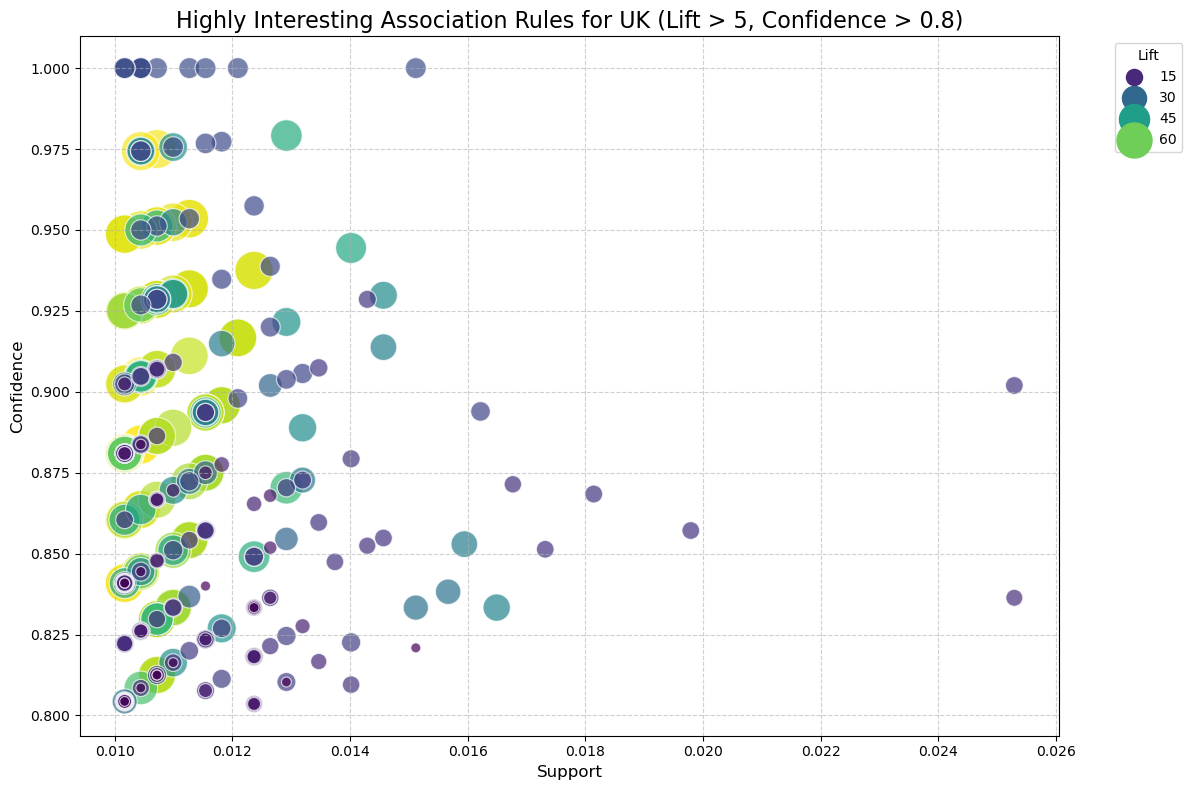


Refined scatter plot for the UK saved as 'uk_association_rules_plot.png' and displayed.


In [8]:
# =========================================================================
#  VISUALIZATION OF ASSOCIATION RULES ===
# =========================================================================
print("\n\n--- Visualizing Association Rules ---")

rules_for_plot = rules_filtered[
    (rules_filtered['lift'] > 5) &
    (rules_filtered['confidence'] > 0.8)
].copy()

if len(rules_for_plot) > 0:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x="support", y="confidence", size="lift", hue="lift",
                    data=rules_for_plot, sizes=(50, 800), palette="viridis", alpha=0.7)

    plt.title('Highly Interesting Association Rules for UK (Lift > 5, Confidence > 0.8)', fontsize=16)
    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('uk_association_rules_plot.png')
    plt.show()
    print("\nRefined scatter plot for the UK saved as 'uk_association_rules_plot.png' and displayed.")
else:
    print("No rules found after applying the stricter filters for UK visualization. Try adjusting the lift/confidence thresholds.")

In [11]:
#  the Presentation-Ready Table ---
print("\n--- Creating Presentation-Ready Table for Executives ---")
top_rules_for_presentation = rules_filtered.head(10).copy()

# Dynamically generate recommendations based on the actual rules
def generate_recommendation(row):
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    
    if len(row['antecedents']) > 1:
        return f"Bundle '{antecedents}' together. Customers who buy these are highly likely to also purchase '{consequents}'."
    else:
        return f"Co-locate '{antecedents}' with '{consequents}' for effective cross-selling."

top_rules_for_presentation['Recommendation'] = top_rules_for_presentation.apply(generate_recommendation, axis=1)

# Clean up the format for the final table
final_table = top_rules_for_presentation[[
    'antecedents',
    'consequents',
    'confidence',
    'lift',
    'Recommendation'
]].copy()

# Convert frozensets to clean strings for easier reading
final_table['antecedents'] = final_table['antecedents'].apply(lambda x: ', '.join(list(x)))
final_table['consequents'] = final_table['consequents'].apply(lambda x: ', '.join(list(x)))
final_table['confidence'] = final_table['confidence'].round(2)
final_table['lift'] = final_table['lift'].round(2)

# Print the final table
print("\nTop 10 Association Rules for the UK (Filtered & Actionable):")
print(final_table.to_string(justify='left', max_colwidth=80))



--- Creating Presentation-Ready Table for Executives ---

Top 10 Association Rules for the UK (Filtered & Actionable):
    antecedents                                consequents                                 confidence  lift  Recommendation                                                                  
522  HERB MARKER ROSEMARY, HERB MARKER PARSLEY       HERB MARKER BASIL, HERB MARKER THYME  0.86        74.81  Bundle 'HERB MARKER ROSEMARY, HERB MARKER PARSLEY' together. Customers who b...
519       HERB MARKER BASIL, HERB MARKER THYME  HERB MARKER ROSEMARY, HERB MARKER PARSLEY  0.90        74.81  Bundle 'HERB MARKER BASIL, HERB MARKER THYME' together. Customers who buy th...
523     HERB MARKER THYME, HERB MARKER PARSLEY    HERB MARKER BASIL, HERB MARKER ROSEMARY  0.88        74.77  Bundle 'HERB MARKER THYME, HERB MARKER PARSLEY' together. Customers who buy ...
518    HERB MARKER BASIL, HERB MARKER ROSEMARY     HERB MARKER THYME, HERB MARKER PARSLEY  0.88        74.77  Bundle 'HE



--- Generating Network Graph Visualization ---


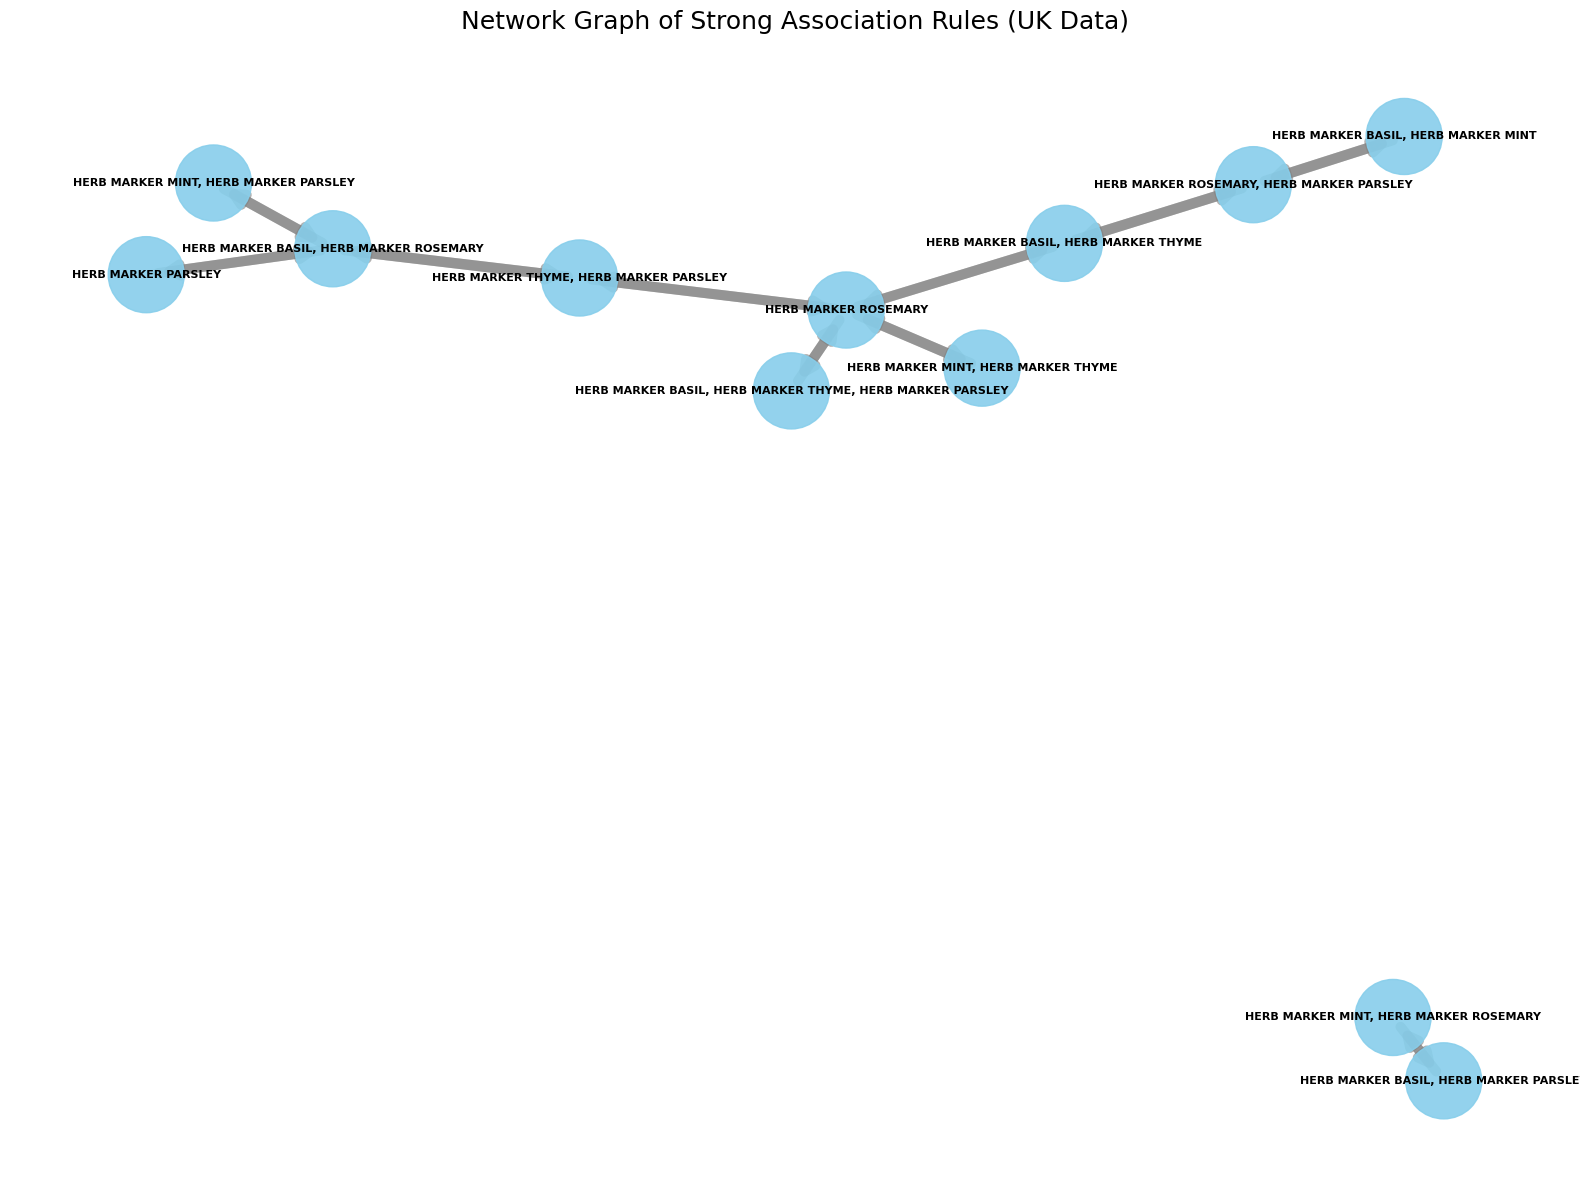


Network graph of Association Rules for UK saved as 'uk_association_rules_network_graph.png' and displayed.


In [15]:
# VISUALIZATION - NETWORK GRAPH ===
# =========================================================================
print("\n\n--- Generating Network Graph Visualization ---")

# Filter rules further for a clearer graph (adjust thresholds as needed)
# A very high lift threshold will show only the strongest, most interesting connections.
# Limiting the number of rules to plot is crucial for readability.
rules_for_graph = rules_filtered[rules_filtered['lift'] > 5].head(20).copy() # Top 20 rules with lift > 5

if not rules_for_graph.empty:
    # Create a directed graph
    G = nx.DiGraph()

    # Add nodes and edges based on the filtered rules
    for _, rule in rules_for_graph.iterrows():
        # Convert frozensets to strings for node names
        antecedent_str = ', '.join(list(rule['antecedents']))
        consequent_str = ', '.join(list(rule['consequents']))

        # Add nodes
        G.add_node(antecedent_str, type='antecedent')
        G.add_node(consequent_str, type='consequent')

        # Add edge with attributes
        G.add_edge(antecedent_str, consequent_str,
                   confidence=rule['confidence'],
                   lift=rule['lift'],
                   weight=rule['lift']) # Use lift as weight for drawing

    # Define node colors based on whether they are antecedents or consequents
    node_colors = []
    for node in G.nodes():
        if node in rules_for_graph['antecedents'].apply(lambda x: ', '.join(list(x))).values:
            node_colors.append('skyblue') # Antecedent
        elif node in rules_for_graph['consequents'].apply(lambda x: ', '.join(list(x))).values:
            node_colors.append('lightcoral') # Consequent
        else:
            node_colors.append('lightgray') # Other nodes (shouldn't be many with this logic)

    # Define edge widths based on lift
    edge_widths = [G[u][v]['lift'] / 10 for u, v in G.edges()] # Scale lift for visual thickness

    # Set up the plot
    plt.figure(figsize=(16, 12)) # Adjust figure size for better visibility

    # Use a spring layout for better node distribution
    pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42) # k adjusts distance, iterations for stability

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

    # Draw edges
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=edge_widths,
                           edge_color='gray', arrowsize=20, alpha=0.6)

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

    # Add edge labels for confidence/lift (optional, can clutter for many edges)
    # edge_labels = nx.get_edge_attributes(G, 'lift')
    # nx.draw_networkx_edge_labels(G, pos, edge_labels={k: round(v, 2) for k, v in edge_labels.items()}, font_size=7)

    plt.title('Network Graph of Strong Association Rules (UK Data)', fontsize=18)
    plt.axis('off') # Hide axes
    plt.tight_layout() # Adjust layout
    plt.savefig('uk_association_rules_network_graph.png', dpi=300) # Save with higher DPI
    plt.show()

    print("\nNetwork graph of Association Rules for UK saved as 'uk_association_rules_network_graph.png' and displayed.")
else:
    print("No rules found after applying the stricter filters for network graph visualization. Try adjusting the 'lift' threshold for 'rules_for_graph'.")


In [20]:
#  Apply Apriori Algorithm ---
print("\n--- Applying Apriori Algorithm ---")
min_support_value = 0.01 # You can adjust this value if needed
frequent_itemsets = apriori(df_encoded, min_support=min_support_value, use_colnames=True)
print(f"Found {len(frequent_itemsets)} frequent itemsets.")

# Optional: Print top frequent itemsets for verification
print("\nFrequent itemsets (top 20 by support):\n", frequent_itemsets.sort_values(by='support', ascending=False).head(20))
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print("\nFrequent itemsets by length (top 20):\n", frequent_itemsets.sort_values(by='length', ascending=False).head(20))







--- Applying Apriori Algorithm ---
Found 2477 frequent itemsets.

Frequent itemsets (top 20 by support):
       support                              itemsets
809  0.116822  (WHITE HANGING HEART T-LIGHT HOLDER)
373  0.108851             (JUMBO BAG RED RETROSPOT)
586  0.094283            (REGENCY CAKESTAND 3 TIER)
494  0.090984                       (PARTY BUNTING)
54   0.075866       (ASSORTED COLOUR BIRD ORNAMENT)
413  0.075041             (LUNCH BAG RED RETROSPOT)
656  0.071743    (SET OF 3 CAKE TINS PANTRY DESIGN)
445  0.067345      (NATURAL SLATE HEART CHALKBOARD)
405  0.067070             (LUNCH BAG  BLACK SKULL.)
472  0.066795     (PACK OF 72 RETROSPOT CAKE CASES)
830  0.064046   (WOODEN PICTURE FRAME WHITE FINISH)
357  0.062672            (JAM MAKING SET WITH JARS)
546  0.062672     (RECIPE BOX PANTRY YELLOW DESIGN)
328  0.061572               (HEART OF WICKER SMALL)
382  0.061572   (JUMBO SHOPPER VINTAGE RED PAISLEY)
384  0.061297              (JUMBO STORAGE BAG SUKI)
371  0.06

In [23]:
# --- 6. Generate Association Rules ---
print("\n--- Generating Association Rules ---")
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7) # You can adjust min_threshold
rules_filtered = rules[rules['lift'] > 1.2].sort_values(by='lift', ascending=False) # You can adjust lift threshold
print(f"Found {len(rules_filtered)} filtered rules.")
print("\nMarket Basket Analysis complete for the UK!") # Corrected: Added missing closing parenthesis



--- Generating Association Rules ---
Found 667 filtered rules.

Market Basket Analysis complete for the UK!


In [24]:
# --- 7. Create the Presentation-Ready Table (Extended to Top 20) ---
print("\n--- Creating Presentation-Ready Table for Executives ---")
# Displaying the top 20 rules by lift for presentation
top_rules_for_presentation = rules_filtered.head(20).copy()

# Dynamically generate recommendations based on the actual rules
def generate_recommendation(row):
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))

    if len(row['antecedents']) > 1:
        return f"Bundle '{antecedents}' together. Customers who buy these are highly likely to also purchase '{consequents}'."
    else:
        return f"Co-locate '{antecedents}' with '{consequents}' for effective cross-selling."

top_rules_for_presentation['Recommendation'] = top_rules_for_presentation.apply(generate_recommendation, axis=1)

# Clean up the format for the final table
final_table = top_rules_for_presentation[[
    'antecedents',
    'consequents',
    'confidence',
    'lift',
    'Recommendation'
]].copy()

# Convert frozensets to clean strings for easier reading
final_table['antecedents'] = final_table['antecedents'].apply(lambda x: ', '.join(list(x)))
final_table['consequents'] = final_table['consequents'].apply(lambda x: ', '.join(list(x)))
final_table['confidence'] = final_table['confidence'].round(2)
final_table['lift'] = final_table['lift'].round(2)

# Print the final table, showing all rules in final_table (which is now top 20)
print("\nTop Association Rules for the UK (Filtered & Actionable):")
print(final_table.to_string(justify='left', max_colwidth=80))

# --- Removed Network Graph Visualization as requested ---
# The previous visualization code has been removed from this version of the Canvas.






--- Creating Presentation-Ready Table for Executives ---

Top Association Rules for the UK (Filtered & Actionable):
    antecedents                                                consequents                                                 confidence  lift  Recommendation                                                                  
522                  HERB MARKER ROSEMARY, HERB MARKER PARSLEY                       HERB MARKER BASIL, HERB MARKER THYME  0.86        74.81  Bundle 'HERB MARKER ROSEMARY, HERB MARKER PARSLEY' together. Customers who b...
519                       HERB MARKER BASIL, HERB MARKER THYME                  HERB MARKER ROSEMARY, HERB MARKER PARSLEY  0.90        74.81  Bundle 'HERB MARKER BASIL, HERB MARKER THYME' together. Customers who buy th...
523                     HERB MARKER THYME, HERB MARKER PARSLEY                    HERB MARKER BASIL, HERB MARKER ROSEMARY  0.88        74.77  Bundle 'HERB MARKER THYME, HERB MARKER PARSLEY' together. Customers who buy

In [25]:
# This code assumes 'frequent_itemsets' DataFrame is already available
# from the successful execution of the Apriori algorithm.

print("\n--- Generating Table for Top 20 Frequent Itemsets by Length ---")

# Ensure the 'length' column is present
if 'length' not in frequent_itemsets.columns:
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Sort by length (descending) and then by support (descending) to get the "longest" and most frequent
# items first, then select the top 20.
top_20_frequent_itemsets_by_length = frequent_itemsets.sort_values(
    by=['length', 'support'], ascending=[False, False]
).head(20).copy()

# Select only the relevant columns for the table
display_table = top_20_frequent_itemsets_by_length[['support', 'itemsets', 'length']].copy()

# Convert frozensets in 'itemsets' column to readable strings
display_table['itemsets'] = display_table['itemsets'].apply(lambda x: ', '.join(list(x)))

# Round support for cleaner display
display_table['support'] = display_table['support'].round(6) # Round to 6 decimal places for consistency

# Print the table
print(display_table.to_string(index=False, justify='left', max_colwidth=80))

print("\nTable generation complete.")



--- Generating Table for Top 20 Frequent Itemsets by Length ---
 support itemsets                                                                          length
0.011545 RED RETROSPOT CHARLOTTE BAG, STRAWBERRY CHARLOTTE BAG, WOODLAND CHARLOTTE BAG... 5      
0.010720 LUNCH BAG  BLACK SKULL., LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY DESIGN, ... 5      
0.010170 LUNCH BAG  BLACK SKULL., LUNCH BAG RED RETROSPOT, LUNCH BAG PINK POLKADOT, LU... 5      
0.010170 LUNCH BAG  BLACK SKULL., LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY DESIGN, ... 5      
0.010170 LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY DESIGN, LUNCH BAG PINK POLKADOT, ... 5      
0.014568 WOODLAND CHARLOTTE BAG, CHARLOTTE BAG PINK POLKADOT, RED RETROSPOT CHARLOTTE ... 4      
0.014294 GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACU... 4      
0.014019 WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOTTE BAG, STRAWBERRY CHARLOTTE BAG... 4      
0.013469 CHARLOTTE BAG PINK POLKADOT, RED RETROSPOT C